In [1]:
import pandas as pd
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt

In [ ]:
# Load the data from the CSV file
df = pd.read_csv("../data/raw/data-v5.csv")

# Display the first few rows to verify the data was loaded correctly
df.head()

,propertyId,postalCode,typeOfProperty,subtypeOfProperty,price,typeOfSale,numberOfRooms,livingArea,equippedKitchen,furnished,...,hasHeatPump,hasPhotovoltaicPanels,hasThermicPanels,hasDoubleGlazing,epcScore,primaryEnergyConsumptionPerSqm,renovationObligation,cadastralIncome,parkingCountIndoor,parkingCountOutdoor
0,4611027,1060,1,19,895000,0,5,0.0,7,0,...,-1,-1,-1,-1,4,179,-1,-1,0,0
1,5075537,3530,1,25,175000,0,1,50.0,-1,0,...,-1,0,0,1,-1,-1,-1,-1,0,0
2,6855719,3583,0,7,1195000,0,1,0.0,-1,0,...,-1,-1,-1,0,2,128,0,-1,0,0
3,7363164,1400,0,0,300000,0,9,255.0,0,0,...,-1,-1,-1,-1,5,402,-1,800,0,0
4,7562151,1861,0,0,1000000,0,8,400.0,-1,0,...,-1,-1,-1,1,4,367,0,1750,2,0


In [3]:
# Replace all -1 values with NaN across the dataframe
df = df.replace(-1, pd.NA)

# Display updated missing values count to verify the changes
updated_missings = df.isna().sum()
print("Updated missing values count:")
print(updated_missings)

Updated missing values count:
propertyId                               0
postalCode                               0
typeOfProperty                           0
subtypeOfProperty                        0
price                                    0
typeOfSale                               0
numberOfRooms                            0
livingArea                               0
equippedKitchen                      30972
furnished                                0
openFire                                 0
garden                               25335
surfaceOfGood                         5427
numberOfFacades                      22319
swimmingPool                             0
stateOfBuilding                      18356
terraceSurface                       41898
hasBasement                          41898
hasDisabledAccess                    15817
hasLift                               8149
livingRoomSurface                    40961
electricalInstallationCertificate    30416
gScore                  

In [4]:
# Filter out any rows with NA latitude/longitude or prices
filtered_df = df[df['latitude'].notna() & df['longitude'].notna() & df['price'].notna()]

# Convert latitude, longitude, and price to numeric values
filtered_df['latitude'] = pd.to_numeric(filtered_df['latitude'])
filtered_df['longitude'] = pd.to_numeric(filtered_df['longitude'])
filtered_df['price'] = pd.to_numeric(filtered_df['price'])

# Get the maximum price from the filtered dataframe
max_price = filtered_df['price'].max()

# Create a figure and axis
plt.figure(figsize=(12, 10))

# Create a scatter plot with heatmap-like appearance
scatter = plt.scatter(
    filtered_df['longitude'], 
    filtered_df['latitude'], 
    c=filtered_df['price'],
    cmap='Reds',
    alpha=0.2,
    s=3,
    norm=LogNorm()
)

# Add a colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Price (EUR)')

# Set labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Property Price Heatmap of Belgium (Max Price: €{max_price:,})')

# Set the limits to focus on Belgium
plt.xlim(2.5, 6.5)
plt.ylim(49.5, 51.5)

# Add grid for better orientation
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


KeyError: 'latitude'

In [ ]:
df_numeric = df.replace(pd.NA, -1).select_dtypes(include=['number'])

df_numeric.dtypes

C:\Users\ImJus\AppData\Local\Temp\ipykernel_65024\3852219888.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric = df.replace(pd.NA, -1).select_dtypes(include=['number'])


propertyId                             int64
postalCode                             int64
typeOfProperty                         int64
subtypeOfProperty                      int64
price                                  int64
typeOfSale                             int64
numberOfRooms                          int64
livingArea                             int64
equippedKitchen                        int64
furnished                              int64
openFire                               int64
garden                                 int64
surfaceOfGood                          int64
numberOfFacades                        int64
swimmingPool                           int64
stateOfBuilding                        int64
latitude                             float64
longitude                            float64
terraceSurface                         int64
hasBasement                            int64
hasDressingRoom                        int64
hasDisabledAccess                      int64
hasLift   

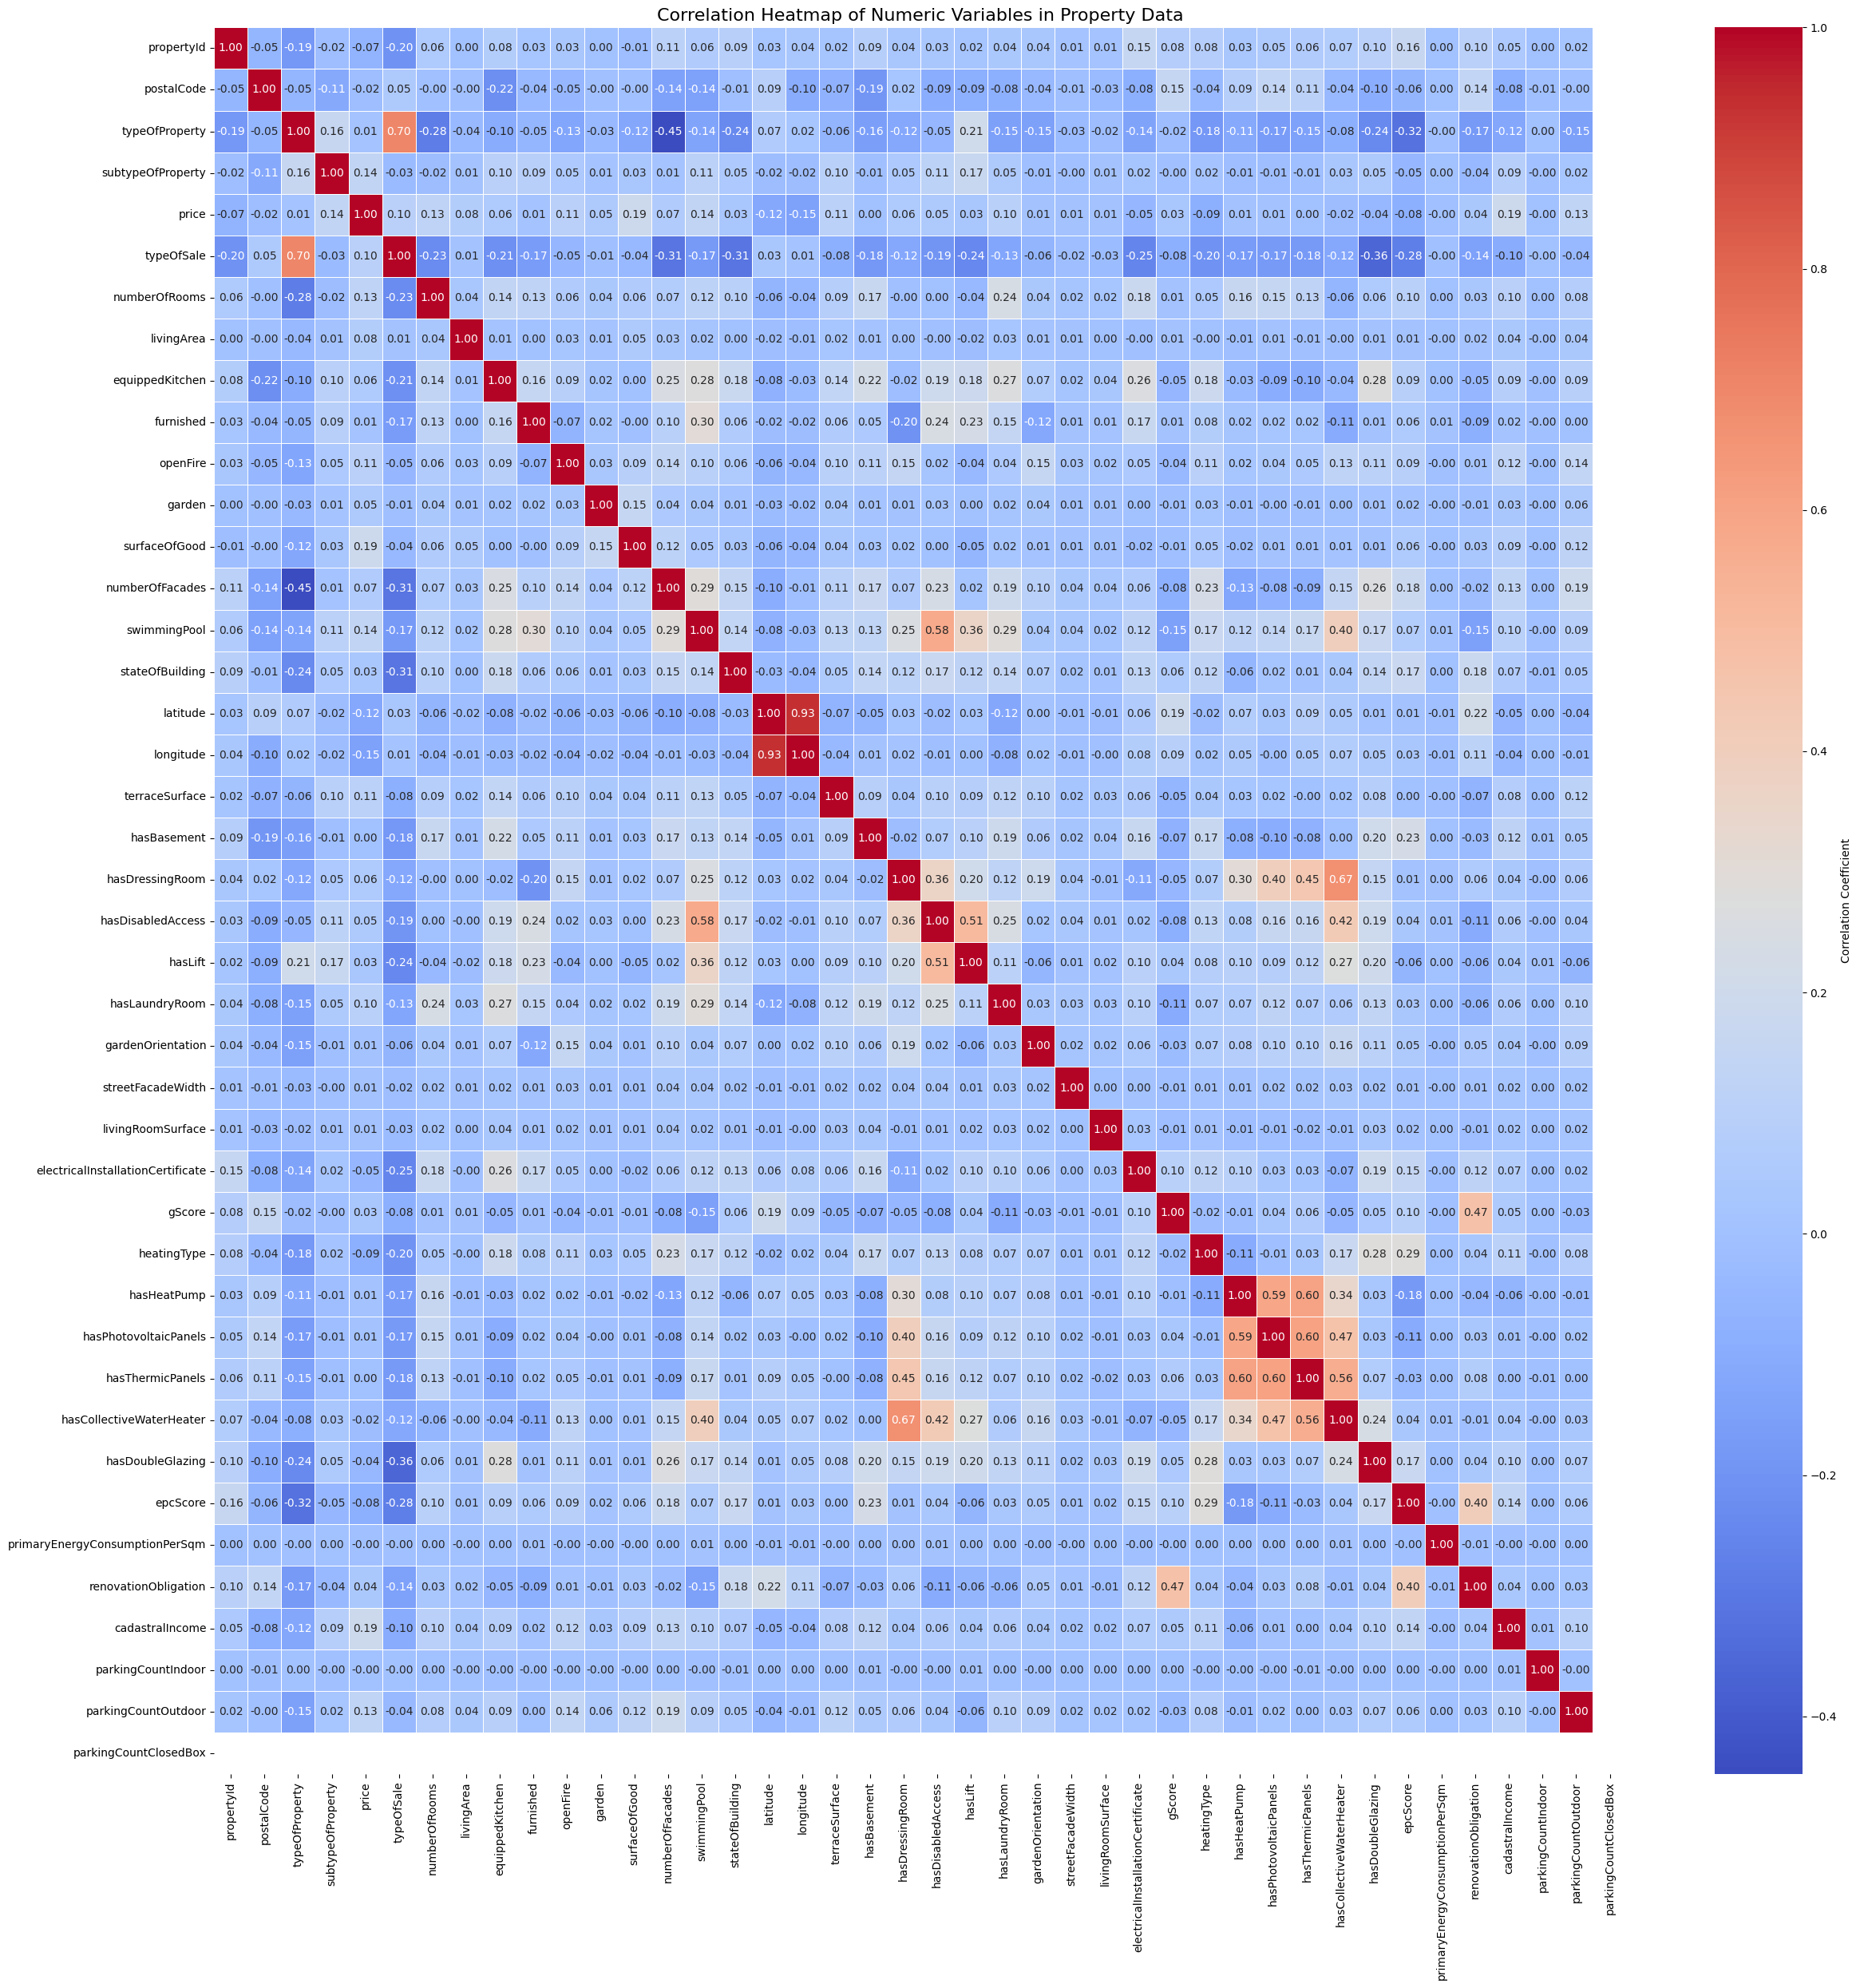

In [ ]:

# Calculate the correlation matrix
correlation_matrix = df_numeric.corr()

# Create a figure with appropriate size
plt.figure(figsize=(25, 25))

# Create a heatmap with value labels
heatmap = sns.heatmap(
    correlation_matrix, 
    annot=True,  # Show values on the heatmap
    cmap='coolwarm',  # Color map
    fmt='.2f',  # Format for the annotations (2 decimal places)
    linewidths=0.5,  # Width of the lines that divide each cell
    cbar_kws={'label': 'Correlation Coefficient'}  # Colorbar label
)

# Set title
plt.title('Correlation Heatmap of Numeric Variables in Property Data', fontsize=16)

# Adjust layout
plt.tight_layout()

# Display the heatmap
plt.show()